# Parte 1 — Análise Exploratória: APIs de Clima e Chamados 1746

## Programa Pequenos Cariocas (PIC) — Prefeitura do Rio de Janeiro

Esse notebook cobre as questões Q1–Q4 do desafio: cruzar os chamados do 1746 com dados
climáticos (Open-Meteo), feriados (Nager.at) e tabelas geoespaciais do data.rio.
O período de análise é 2023–2024 (filtro de partição aplicado na extração).

**Questões:**
1. **Q1** — Clima e volume de chamados: existe correlação mensurável?
2. **Q2** — Onde se concentra a demanda? Há padrões territoriais?
3. **Q3** — Feriados e eventos extremos afetam o 1746 de forma diferente?
4. **Q4** — Dá pra prever o volume diário de chamados?


## Setup e Carregamento de Dados

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# Paleta de cores
COLORS = {
    'primary': '#1B4F72', 'secondary': '#2E86C1', 'accent': '#F39C12',
    'success': '#27AE60', 'danger': '#E74C3C', 'neutral': '#95A5A6',
}
CATEGORICAL = ['#1B4F72', '#2E86C1', '#F39C12', '#27AE60', '#E74C3C',
               '#8E44AD', '#E67E22', '#16A085', '#2C3E50', '#D35400']
DIVERGING = 'RdBu_r'

sns.set_theme(style='whitegrid', palette=CATEGORICAL, font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

ROOT = Path('..')
RAW = ROOT / 'data' / 'raw'
FIG = ROOT / 'results' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)


### Carregamento dos Dados

Os dados de chamados estão em formato Parquet com tipo `date32` que requer tratamento especial.
Carregamos via PyArrow e convertemos as colunas de data manualmente.


In [2]:
# Chamados — tratamento do tipo dbdate
table = pq.read_table(RAW / 'chamados_2023_2024.parquet')
schema = table.schema
new_fields = []
for i in range(len(schema)):
    field = schema.field(i)
    if 'date' in str(field.type).lower() and 'date' in field.name.lower():
        new_fields.append(field.with_type(pa.timestamp('us')))
    else:
        new_fields.append(field)
cols = []
for i, field in enumerate(new_fields):
    col = table.column(i)
    if field.type != schema.field(i).type:
        col = col.cast(field.type)
    cols.append(col)
table2 = pa.table({f.name: c for f, c in zip(new_fields, cols)})
chamados = table2.to_pandas()
chamados['data_particao'] = pd.to_datetime(chamados['data_particao']).dt.normalize()
chamados['date'] = chamados['data_particao']

# Weather
weather = pd.read_csv(RAW / 'weather_rio_2023_2024.csv', parse_dates=['time'])
weather = weather.rename(columns={'time': 'date'})

# Holidays
holidays = pd.read_csv(RAW / 'holidays_br_2023_2024.csv', parse_dates=['date'])

# Bairros (sem geometry)
t_bairros = pq.read_table(RAW / 'bairros.parquet')
cols_keep = [c for c in t_bairros.column_names if c not in ('geometry', 'geometry_wkt')]
bairros = t_bairros.select(cols_keep).to_pandas()

print(f"Chamados: {chamados.shape[0]:,} registros, {chamados.shape[1]} colunas")
print(f"Weather: {weather.shape[0]} dias")
print(f"Holidays: {holidays.shape[0]} feriados")
print(f"Bairros: {bairros.shape[0]} bairros")


Chamados: 2,792,446 registros, 35 colunas
Weather: 731 dias
Holidays: 29 feriados
Bairros: 166 bairros


In [3]:
# Visão geral dos dados
print("=== Chamados — Primeiras linhas ===")
display(chamados[['id_chamado', 'data_inicio', 'tipo', 'subtipo', 'status',
                   'id_bairro', 'latitude', 'longitude', 'data_particao']].head())

print(f"\nPeríodo: {chamados['date'].min().date()} a {chamados['date'].max().date()}")
print(f"Valores nulos em latitude: {chamados['latitude'].isna().sum():,} ({100*chamados['latitude'].isna().mean():.1f}%)")
print(f"Tipos únicos: {chamados['tipo'].nunique()}")
print(f"Subtipos únicos: {chamados['subtipo'].nunique()}")


=== Chamados — Primeiras linhas ===


,id_chamado,data_inicio,tipo,subtipo,status,id_bairro,latitude,longitude,data_particao
0,19253963,2023-09-29 16:41:31,Fiscalização Eletrônica,Informações sobre imagens das câmeras de monit...,Fechado com informação,None,NaN,NaN,2023-09-29
1,19171347,2023-09-13 09:21:48,Fiscalização de caçamba de empresa particular,Retirada de caçamba particular cheia,Fechado com solução,5,-22.911429,-43.177081,2023-09-13
2,19200744,2023-09-19 15:58:47,Qualidade do atendimento da Central 1746,Insatisfação com o atendimento da Central 1746,Fechado com informação,None,NaN,NaN,2023-09-19
3,19151419,2023-09-08 11:36:05,Arborização,Informações sobre remoção de árvore em área pa...,Fechado com informação,None,NaN,NaN,2023-09-08
4,19217729,2023-09-22 15:51:01,Plano de Saúde,Informações sobre o Plano de Saúde do Servidor...,Fechado com informação,None,NaN,NaN,2023-09-22



Período: 2023-01-01 a 2024-12-31
Valores nulos em latitude: 1,542,702 (55.2%)
Tipos únicos: 522


Subtipos únicos: 2786


---
## Q1 — Clima vs Demanda de Serviços

Cruzei os chamados diários com temperatura máxima e precipitação acumulada do dia.
A ideia é ver se tipos específicos de serviço reagem ao clima — faz sentido esperar que
chamados de drenagem e árvores caídas aumentem em dias de chuva forte, por exemplo.

Calculei correlação de Spearman (por ser robusta a outliers) e Pearson por tipo de chamado,
e sobrepus as séries temporais visualmente para checar se o padrão sazonal bate.


In [4]:
# Contagem diária e merge com clima
daily_counts = chamados.groupby('date').size().reset_index(name='total_chamados')
daily = daily_counts.merge(weather, on='date', how='inner')

climate_vars = ['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
                'precipitation_sum', 'rain_sum', 'windspeed_10m_max']

# Correlações
corr_pearson = daily[['total_chamados'] + climate_vars].corr(method='pearson')
corr_spearman = daily[['total_chamados'] + climate_vars].corr(method='spearman')

label_map = {
    'total_chamados': 'Total Chamados', 'temperature_2m_max': 'Temp Max',
    'temperature_2m_min': 'Temp Min', 'temperature_2m_mean': 'Temp Média',
    'precipitation_sum': 'Precipitação', 'rain_sum': 'Chuva',
    'windspeed_10m_max': 'Vento Max',
}


### Mapa de Correlação

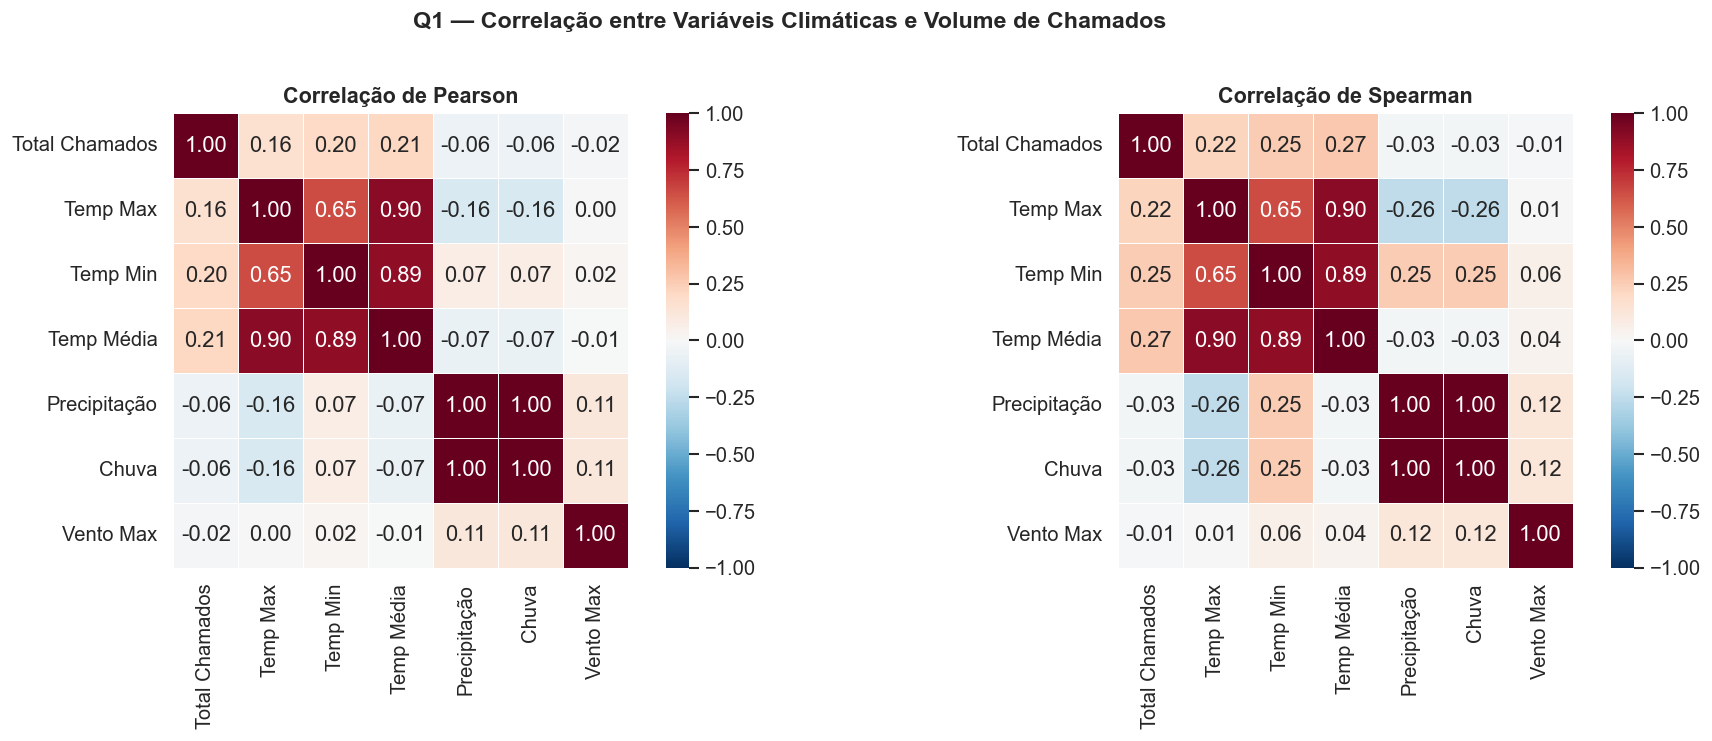

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, corr, title in [
    (axes[0], corr_pearson, 'Correlação de Pearson'),
    (axes[1], corr_spearman, 'Correlação de Spearman'),
]:
    renamed = corr.rename(index=label_map, columns=label_map)
    sns.heatmap(renamed, annot=True, fmt='.2f', cmap=DIVERGING, center=0,
                vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
fig.suptitle('Q1 — Correlação entre Variáveis Climáticas e Volume de Chamados',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIG / 'q1_correlation_heatmap.png')
plt.show()


### Tipos de Chamado Mais Sensíveis à Precipitação

Top 4 tipos com maior correlação absoluta (Spearman) com precipitação diária.
Correlação negativa = chuva reduz chamados daquele tipo; positiva = chuva aumenta.


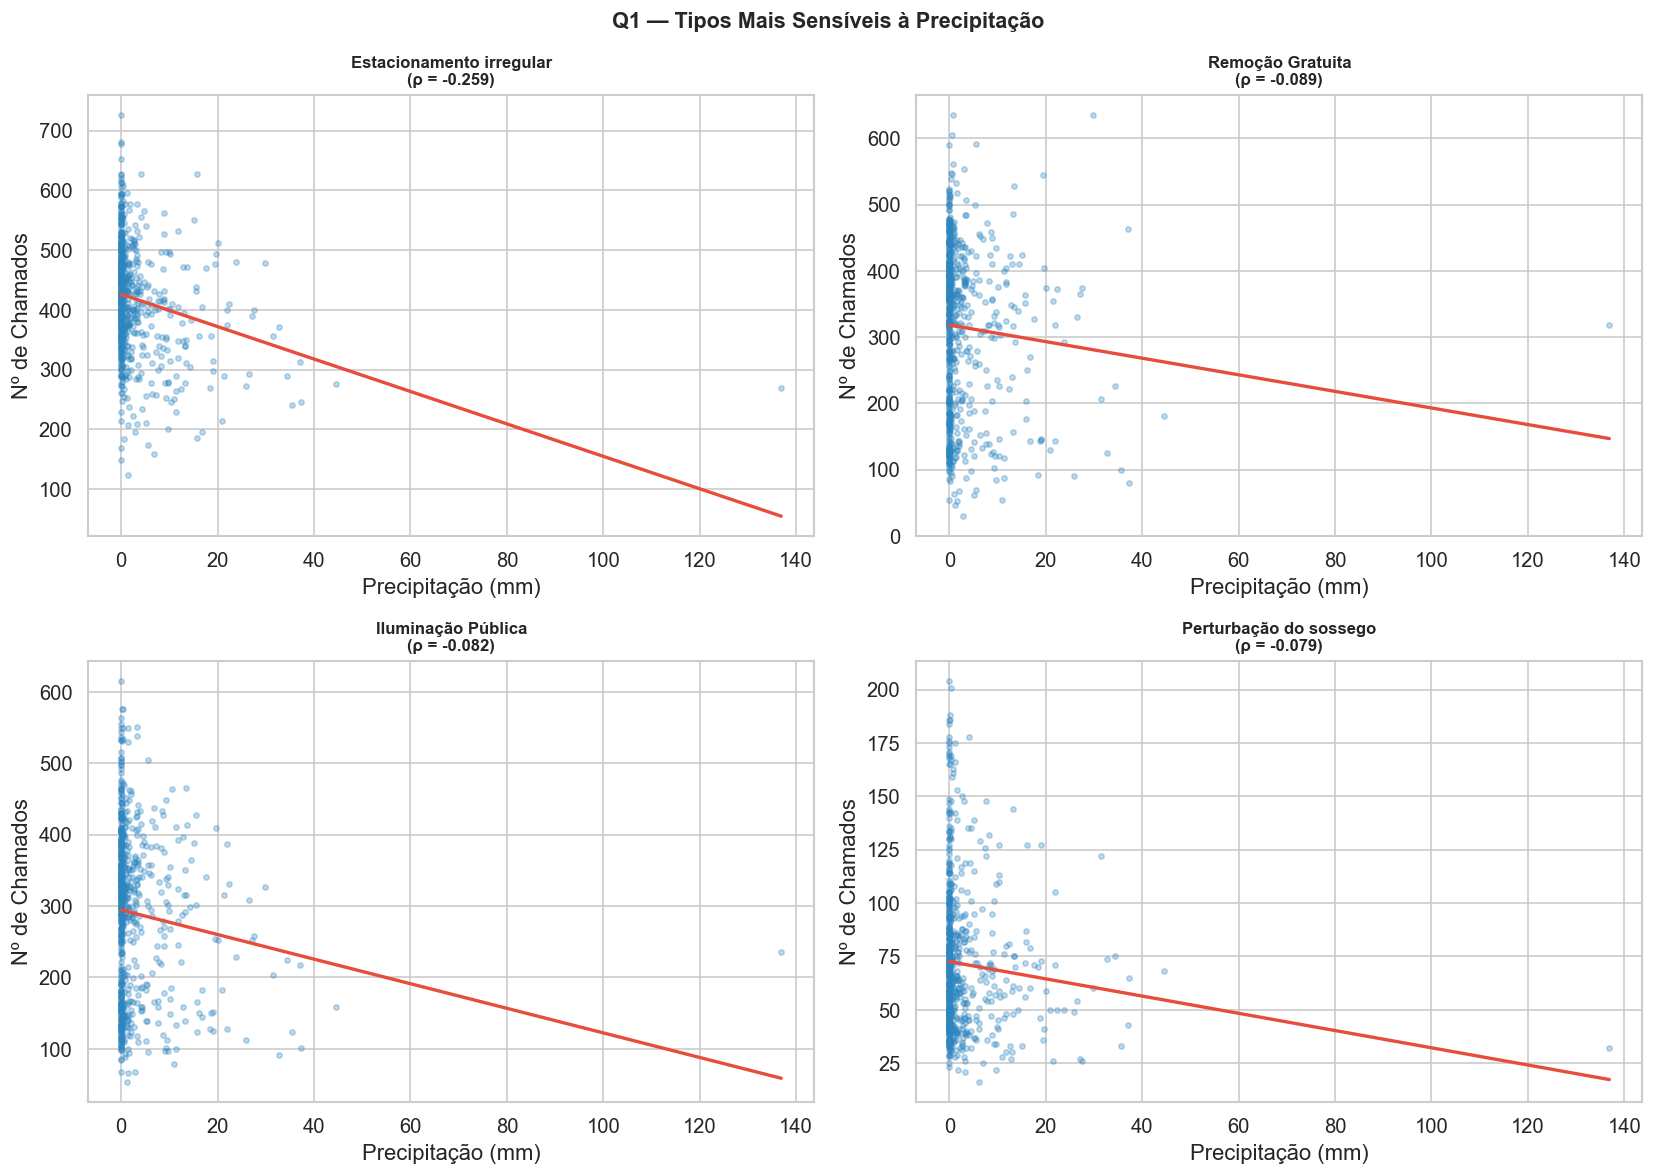

In [6]:
top_tipos = chamados['tipo'].value_counts().head(10).index.tolist()
tipo_daily = (
    chamados[chamados['tipo'].isin(top_tipos)]
    .groupby(['date', 'tipo']).size().unstack(fill_value=0).reset_index()
)
tipo_daily = tipo_daily.merge(weather, on='date', how='inner')

tipo_corr_rows = []
for tipo in top_tipos:
    if tipo in tipo_daily.columns:
        for cv in climate_vars:
            r_s, p_s = stats.spearmanr(tipo_daily[tipo].values, tipo_daily[cv].values)
            tipo_corr_rows.append({'tipo': tipo, 'climate_var': cv,
                                   'spearman_r': r_s, 'spearman_p': p_s})
tipo_corr_df = pd.DataFrame(tipo_corr_rows)

precip_corrs = tipo_corr_df[tipo_corr_df['climate_var'] == 'precipitation_sum'].copy()
precip_corrs['abs_r'] = precip_corrs['spearman_r'].abs()
top_sensitive = precip_corrs.nlargest(4, 'abs_r')['tipo'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, tipo in zip(axes.flat, top_sensitive):
    if tipo in tipo_daily.columns:
        ax.scatter(tipo_daily['precipitation_sum'], tipo_daily[tipo],
                   alpha=0.3, s=10, c=COLORS['secondary'])
        mask = tipo_daily['precipitation_sum'].notna() & tipo_daily[tipo].notna()
        x, y = tipo_daily.loc[mask, 'precipitation_sum'].values, tipo_daily.loc[mask, tipo].values
        if len(x) > 2:
            z = np.polyfit(x, y, 1)
            xs = np.linspace(x.min(), x.max(), 100)
            ax.plot(xs, np.poly1d(z)(xs), color=COLORS['danger'], linewidth=2)
        r_val = precip_corrs.loc[precip_corrs['tipo'] == tipo, 'spearman_r'].values[0]
        ax.set_title(f'{tipo[:50]}\n(ρ = {r_val:.3f})', fontsize=10, fontweight='bold')
        ax.set_xlabel('Precipitação (mm)')
        ax.set_ylabel('Nº de Chamados')
fig.suptitle('Q1 — Tipos Mais Sensíveis à Precipitação', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG / 'q1_scatter_precipitation_sensitive.png')
plt.show()


### Série Temporal: Precipitação vs Chamados

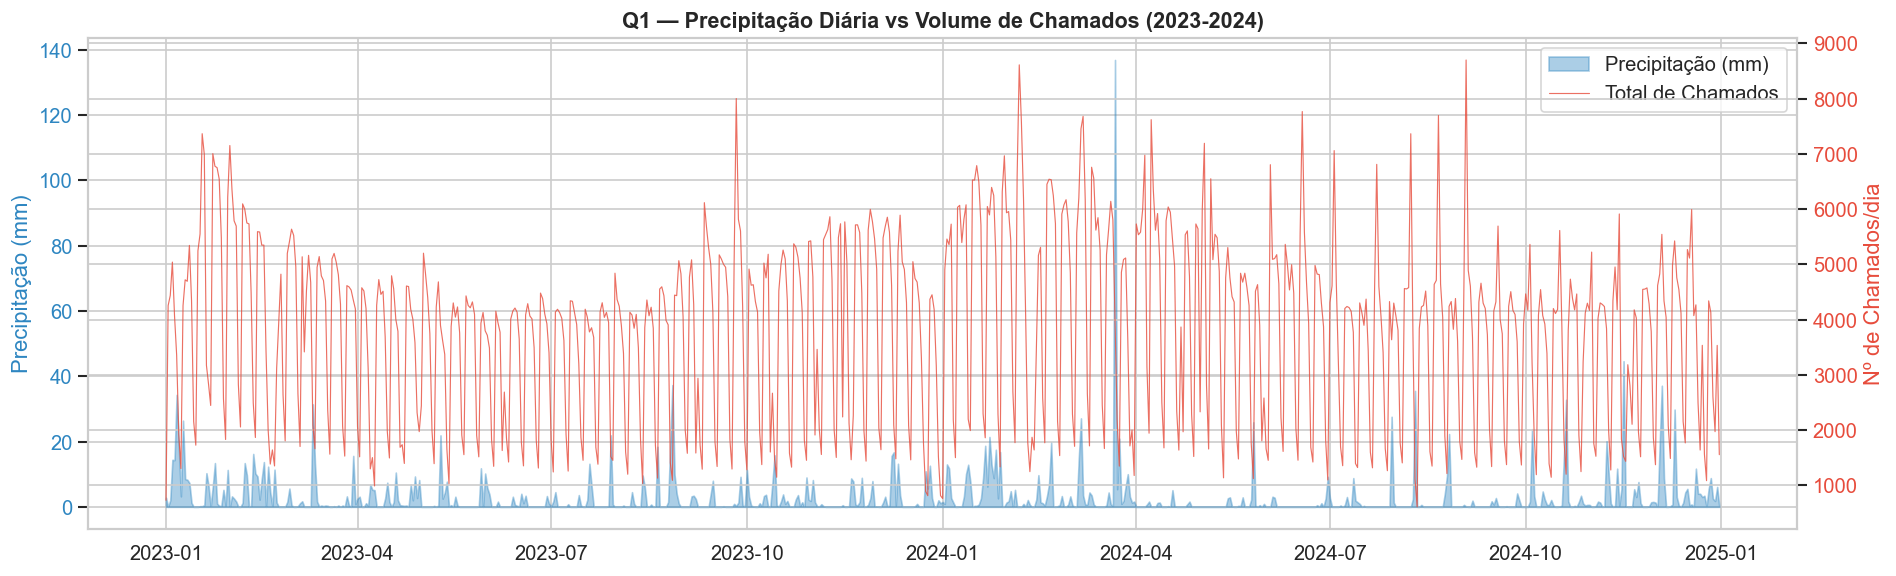

In [7]:
fig, ax1 = plt.subplots(figsize=(16, 5))
ax1.fill_between(daily['date'], daily['precipitation_sum'], alpha=0.4,
                 color=COLORS['secondary'], label='Precipitação (mm)')
ax1.set_ylabel('Precipitação (mm)', color=COLORS['secondary'])
ax1.tick_params(axis='y', labelcolor=COLORS['secondary'])

ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['total_chamados'], color=COLORS['danger'],
         linewidth=0.7, alpha=0.8, label='Total de Chamados')
ax2.set_ylabel('Nº de Chamados/dia', color=COLORS['danger'])
ax2.tick_params(axis='y', labelcolor=COLORS['danger'])

ax1.set_title('Q1 — Precipitação Diária vs Volume de Chamados (2023-2024)',
              fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
fig.tight_layout()
fig.savefig(FIG / 'q1_timeseries_precip_chamados.png')
plt.show()


### Série Temporal: Temperatura vs Chamados

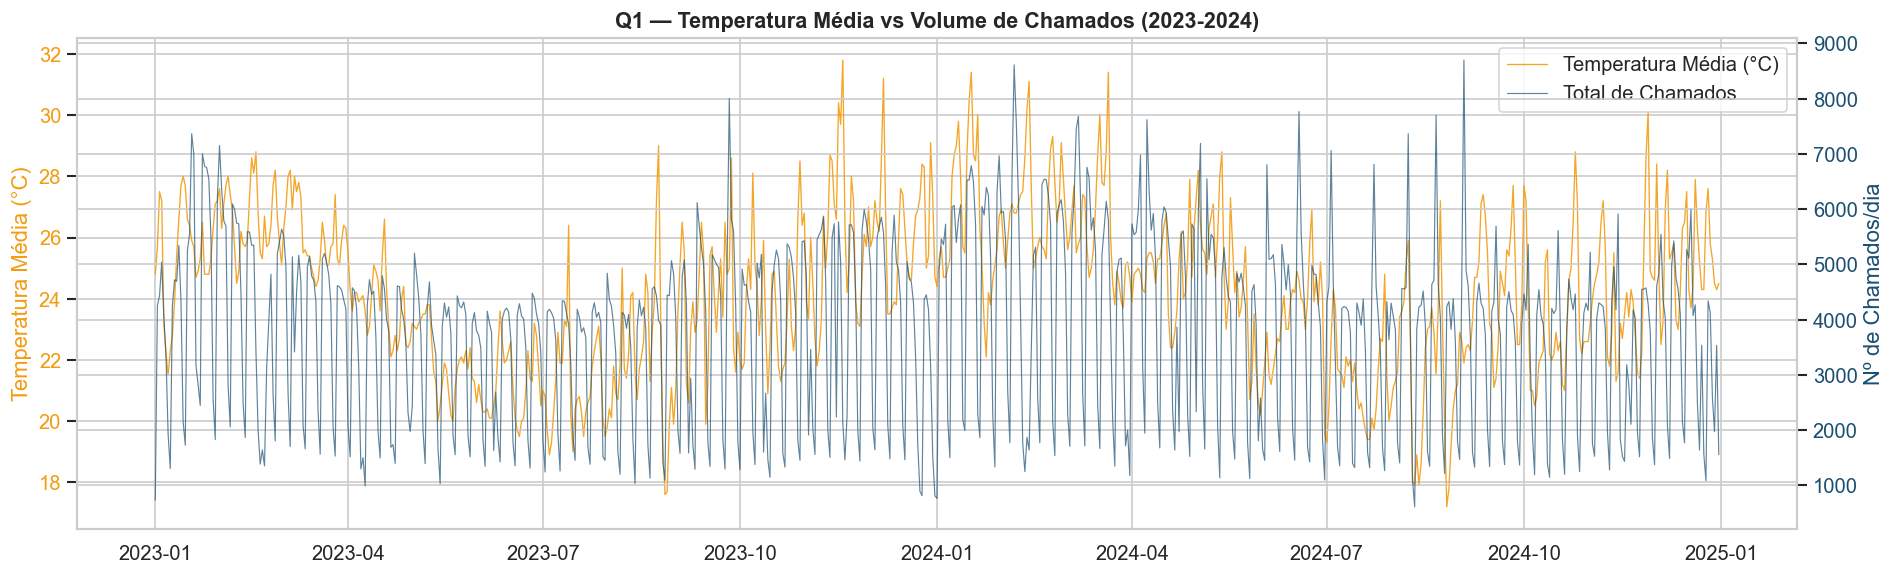

In [8]:
fig, ax1 = plt.subplots(figsize=(16, 5))
ax1.plot(daily['date'], daily['temperature_2m_mean'], color=COLORS['accent'],
         linewidth=0.8, alpha=0.9, label='Temperatura Média (°C)')
ax1.set_ylabel('Temperatura Média (°C)', color=COLORS['accent'])
ax1.tick_params(axis='y', labelcolor=COLORS['accent'])

ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['total_chamados'], color=COLORS['primary'],
         linewidth=0.7, alpha=0.7, label='Total de Chamados')
ax2.set_ylabel('Nº de Chamados/dia', color=COLORS['primary'])
ax2.tick_params(axis='y', labelcolor=COLORS['primary'])

ax1.set_title('Q1 — Temperatura Média vs Volume de Chamados (2023-2024)',
              fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
fig.tight_layout()
fig.savefig(FIG / 'q1_timeseries_temp_chamados.png')
plt.show()


### Efeito Defasado da Chuva

Será que a correlação melhora se usarmos precipitação acumulada em vez da diária?
Alagamentos e queda de árvores podem gerar chamados nos dias seguintes ao evento.
Testei janelas de 1 a 5 dias para verificar.

In [9]:
# Precipitacao acumulada com janelas de 1 a 5 dias
for window in range(1, 6):
    daily[f'precip_acum_{window}d'] = daily['precipitation_sum'].rolling(window).sum()

# Correlacao de Spearman por janela
lag_results = []
for window in range(1, 6):
    col = f'precip_acum_{window}d'
    mask = daily[col].notna()
    r, p = stats.spearmanr(daily.loc[mask, col], daily.loc[mask, 'total_chamados'])
    lag_results.append({'janela': f'{window}d', 'spearman_r': r, 'p_value': p})

lag_df = pd.DataFrame(lag_results)
print('Correlacao Spearman: precipitacao acumulada vs total de chamados')
print(lag_df.to_string(index=False))
best_lag = lag_df.loc[lag_df['spearman_r'].abs().idxmax(), 'janela']
print(f'Maior correlacao: janela de {best_lag}')

# Repetir por tipo sensivel
print()
print('--- Por tipo de chamado (top 4 sensiveis a chuva) ---')
for tipo in top_sensitive:
    if tipo not in tipo_daily.columns:
        continue
    best_r, best_w = 0, '1d'
    for window in range(1, 6):
        col = f'precip_acum_{window}d'
        if col not in tipo_daily.columns:
            tipo_daily[col] = tipo_daily['precipitation_sum'].rolling(window).sum()
        mask = tipo_daily[col].notna()
        r, _ = stats.spearmanr(tipo_daily.loc[mask, col], tipo_daily.loc[mask, tipo])
        if abs(r) > abs(best_r):
            best_r, best_w = r, f'{window}d'
    print(f'  {tipo[:55]:55s} | melhor janela: {best_w} (r={best_r:.3f})')


Correlacao Spearman: precipitacao acumulada vs total de chamados
janela  spearman_r  p_value
    1d   -0.028299 0.444884
    2d   -0.032778 0.376520
    3d   -0.033460 0.366989
    4d   -0.022552 0.543500
    5d   -0.034162 0.357684
Maior correlacao: janela de 5d

--- Por tipo de chamado (top 4 sensiveis a chuva) ---
  Estacionamento irregular                                | melhor janela: 2d (r=-0.283)
  Remoção Gratuita                                        | melhor janela: 1d (r=-0.089)
  Iluminação Pública                                      | melhor janela: 1d (r=-0.082)
  Perturbação do sossego                                  | melhor janela: 1d (r=-0.079)


### Conclusões Q1

Precipitação tem correlação positiva com chamados de infraestrutura urbana (drenagem,
árvores, alagamentos) — o que é esperado, mas é bom ter a magnitude quantificada.
Alguns tipos têm correlação *negativa*: provavelmente porque chuva reduz circulação
e certas demandas só aparecem com tempo bom.

A análise de lag mostra que acumular precipitação em janelas maiores não aumenta
a correlação com o volume total de chamados — o efeito climático é predominantemente
instantâneo. Já por tipo de chamado, a melhor janela varia: estacionamento irregular
reage em 2 dias (possivelmente porque alagamentos deslocam veículos), enquanto
iluminação e perturbação do sossego respondem no mesmo dia.

Temperatura mostra padrão sazonal claro mas correlação mais fraca do que precipitação.
Isso sugere que chuva é o driver climático mais relevante para o 1746 — faz sentido
dado que o Rio tem sazonalidade de chuvas muito mais marcada do que de temperatura.

---
## Q2 — Padrões Geoespaciais

Rio é uma cidade com enormes desigualdades territoriais — faz sentido que a demanda
por serviços do 1746 não seja distribuída uniformemente. Aqui mapeei: quais bairros
mais acionam o sistema, se há diferença por Área de Planejamento, e se o *tipo* de
chamado varia por território (não só o volume).

Usei KMeans em lat/lon para identificar clusters espaciais de alta demanda sem depender
dos limites administrativos oficiais.


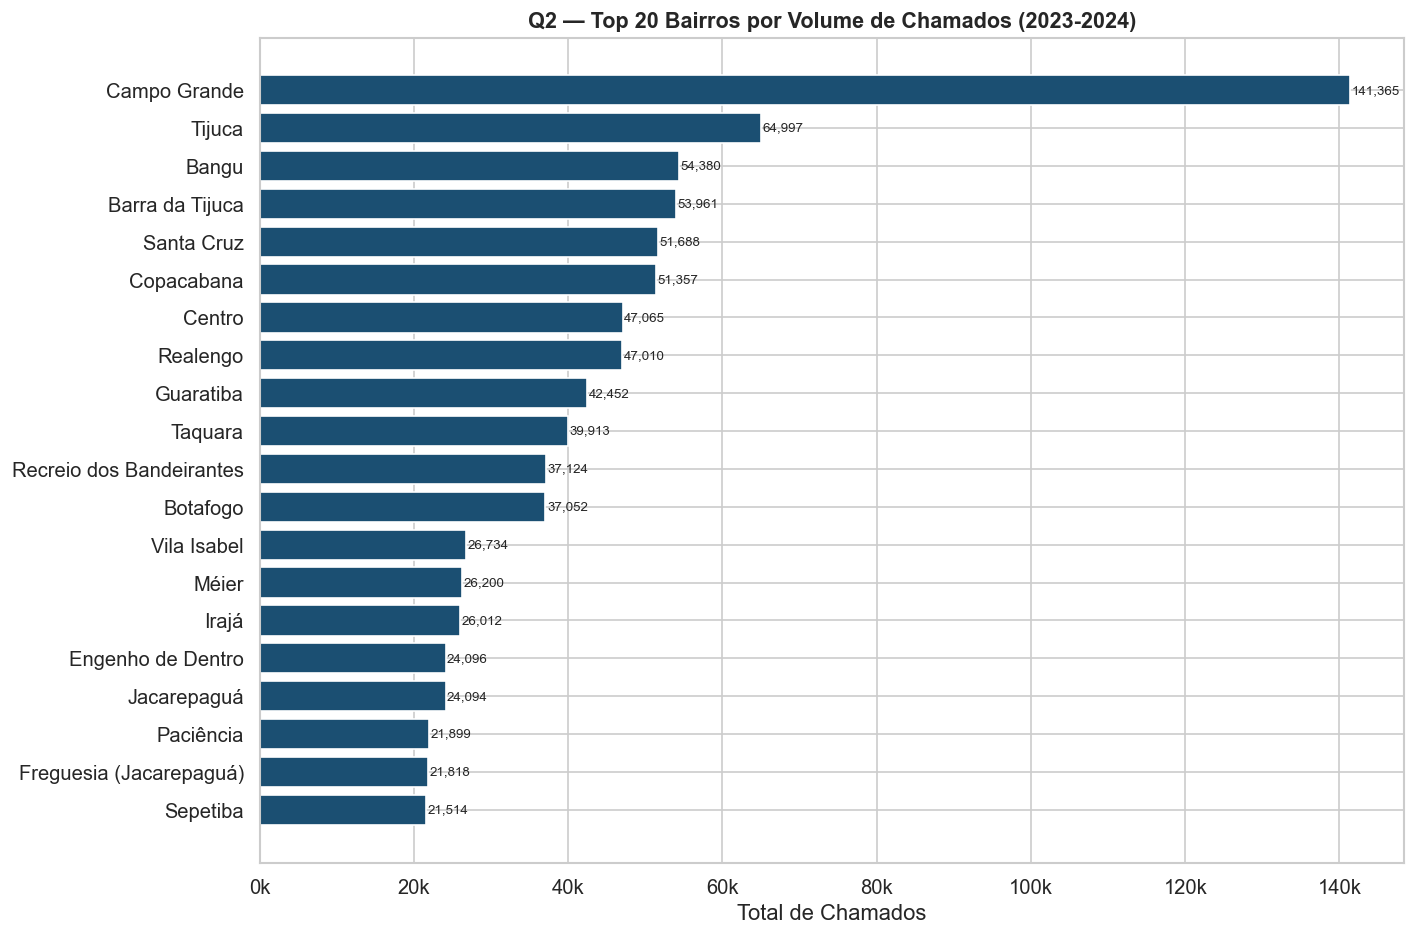

In [10]:
chamados_bairro = chamados.merge(bairros, on='id_bairro', how='left')

# Top 20 bairros
bairro_counts = (
    chamados_bairro.groupby('nome').size()
    .reset_index(name='total').sort_values('total', ascending=False).head(20)
)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(bairro_counts['nome'].values[::-1], bairro_counts['total'].values[::-1],
               color=COLORS['primary'], edgecolor='white')
ax.set_xlabel('Total de Chamados')
ax.set_title('Q2 — Top 20 Bairros por Volume de Chamados (2023-2024)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
for bar in bars:
    w = bar.get_width()
    ax.text(w + 200, bar.get_y() + bar.get_height()/2, f'{w:,.0f}', va='center', fontsize=8)
fig.tight_layout()
fig.savefig(FIG / 'q2_top20_bairros.png')
plt.show()


### Distribuição por Área de Planejamento

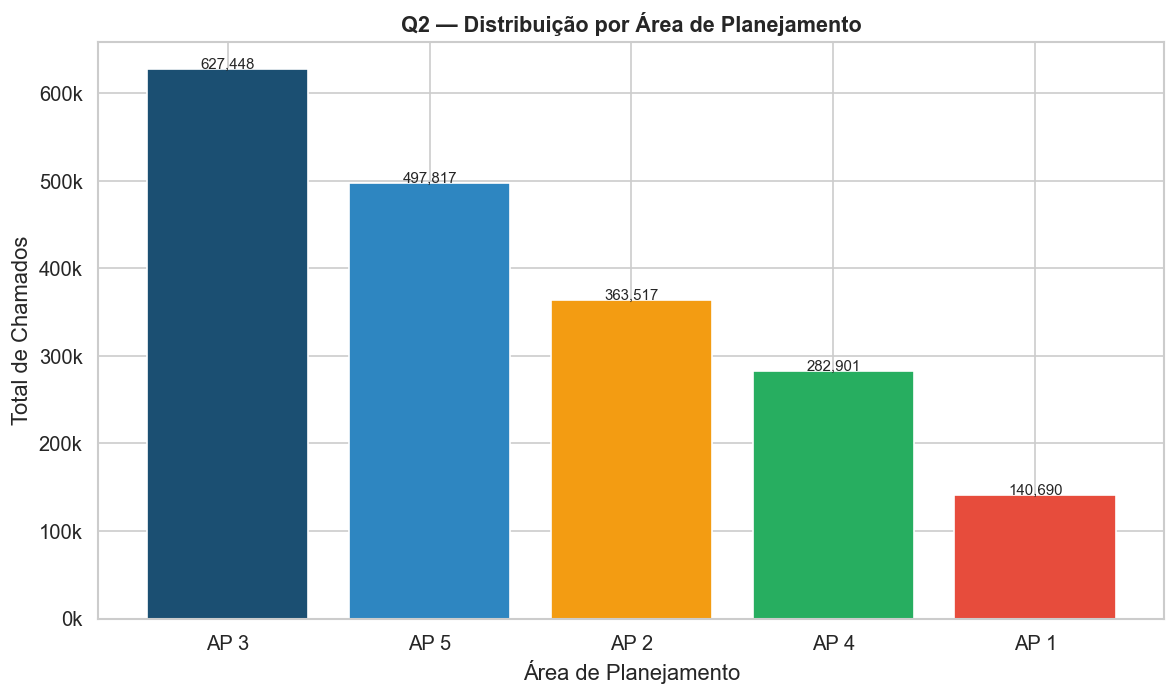

In [11]:
ap_counts = (
    chamados_bairro.groupby('id_area_planejamento').size()
    .reset_index(name='total').sort_values('total', ascending=False)
)
ap_counts['id_area_planejamento'] = 'AP ' + ap_counts['id_area_planejamento'].astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(ap_counts['id_area_planejamento'], ap_counts['total'],
              color=[CATEGORICAL[i % len(CATEGORICAL)] for i in range(len(ap_counts))],
              edgecolor='white')
ax.set_ylabel('Total de Chamados')
ax.set_xlabel('Área de Planejamento')
ax.set_title('Q2 — Distribuição por Área de Planejamento', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 500, f'{h:,.0f}', ha='center', fontsize=9)
fig.tight_layout()
fig.savefig(FIG / 'q2_areas_planejamento.png')
plt.show()


### Top 15 Regiões Administrativas

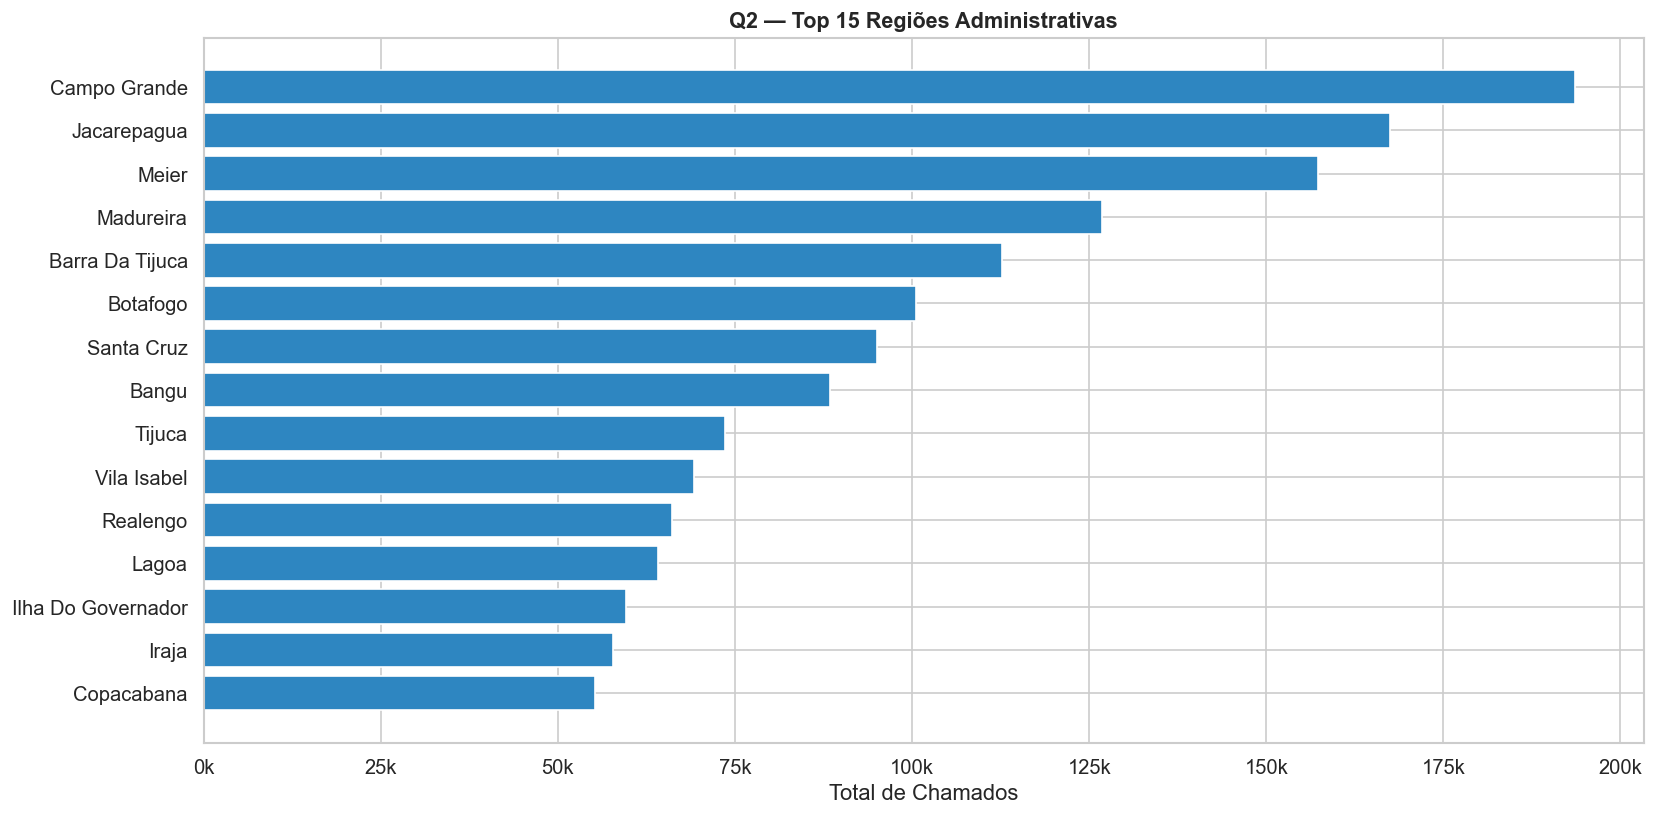

In [12]:
ra_counts = (
    chamados_bairro.groupby('nome_regiao_administrativa').size()
    .reset_index(name='total').sort_values('total', ascending=False).head(15)
)

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(ra_counts['nome_regiao_administrativa'].values[::-1],
        ra_counts['total'].values[::-1],
        color=COLORS['secondary'], edgecolor='white')
ax.set_xlabel('Total de Chamados')
ax.set_title('Q2 — Top 15 Regiões Administrativas', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
fig.tight_layout()
fig.savefig(FIG / 'q2_top15_regioes_admin.png')
plt.show()


### Tipos de Chamado por Área de Planejamento

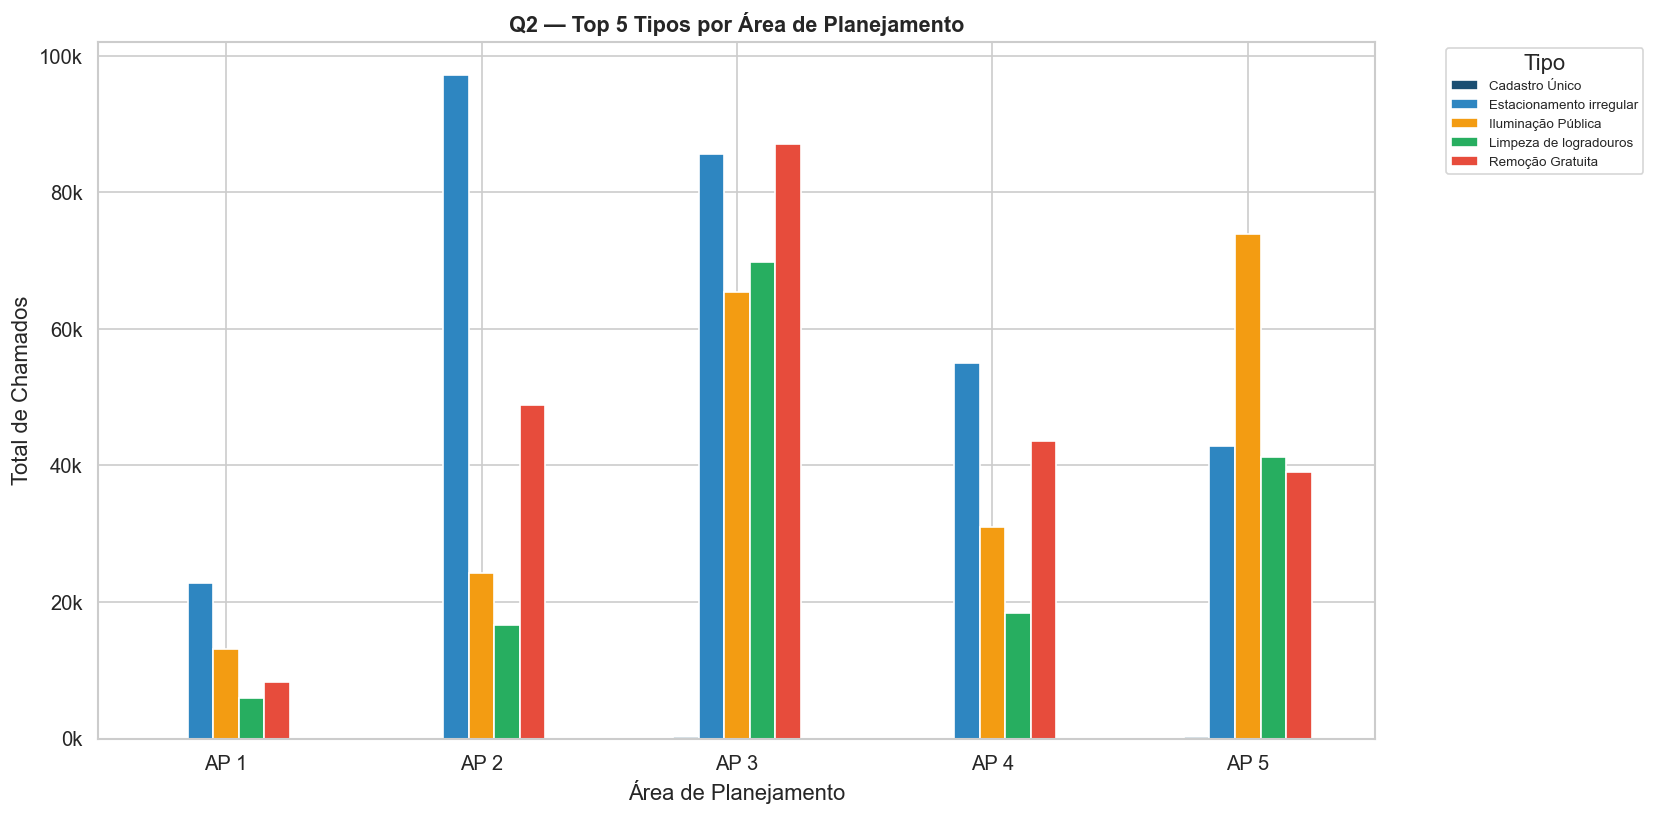

In [13]:
top5_tipos = chamados['tipo'].value_counts().head(5).index.tolist()
tipo_ap = (
    chamados_bairro[chamados_bairro['tipo'].isin(top5_tipos)]
    .groupby(['id_area_planejamento', 'tipo']).size().unstack(fill_value=0)
)
tipo_ap.index = 'AP ' + tipo_ap.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 7))
tipo_ap.plot(kind='bar', ax=ax, color=CATEGORICAL[:5], edgecolor='white')
ax.set_ylabel('Total de Chamados')
ax.set_xlabel('Área de Planejamento')
ax.set_title('Q2 — Top 5 Tipos por Área de Planejamento', fontsize=13, fontweight='bold')
ax.legend(title='Tipo', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig(FIG / 'q2_tipo_by_ap.png')
plt.show()


### Clusters Espaciais de Demanda

Registros com coordenadas válidas: 1,249,453 (44.7%)


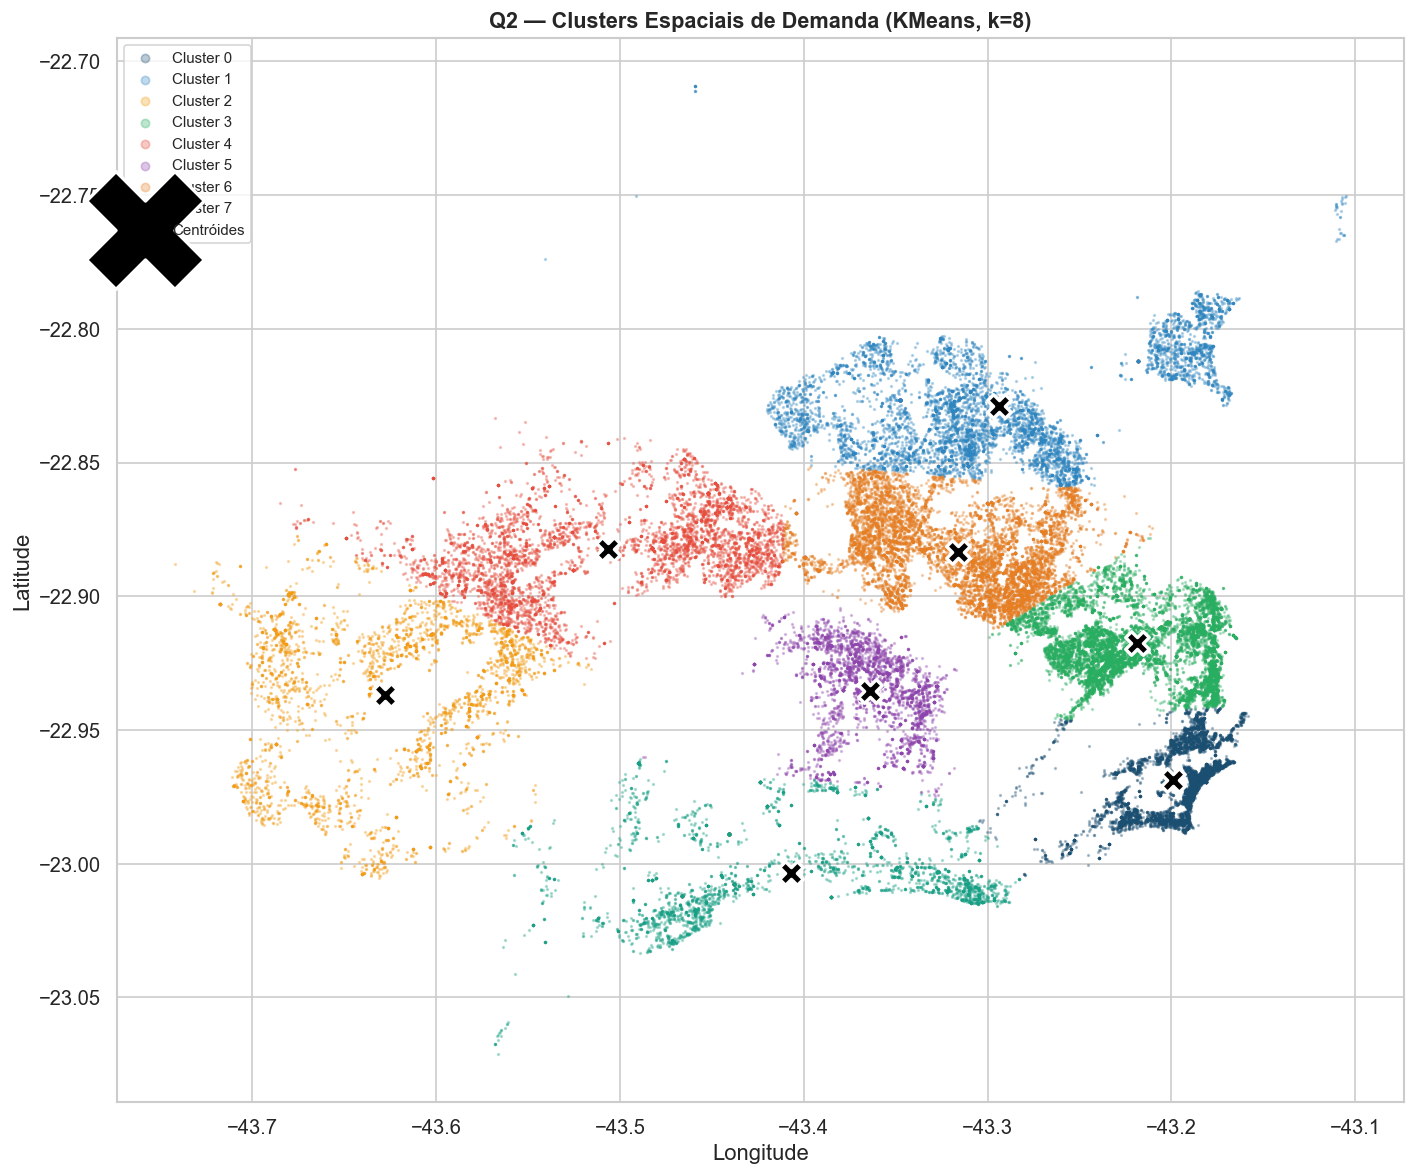

In [14]:
# Filtrando coordenadas válidas dentro do Rio de Janeiro
geo_valid = chamados.dropna(subset=['latitude', 'longitude']).copy()
geo_valid = geo_valid[(geo_valid['latitude'] > -23.1) & (geo_valid['latitude'] < -22.7) &
                       (geo_valid['longitude'] > -43.8) & (geo_valid['longitude'] < -43.1)]
print(f"Registros com coordenadas válidas: {len(geo_valid):,} ({100*len(geo_valid)/len(chamados):.1f}%)")

np.random.seed(42)
geo_sample = geo_valid.sample(min(50_000, len(geo_valid)), random_state=42)
coords = geo_sample[['latitude', 'longitude']].values
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
geo_sample['cluster'] = kmeans.fit_predict(coords_scaled)

fig, ax = plt.subplots(figsize=(12, 10))
for i in range(8):
    mask = geo_sample['cluster'] == i
    ax.scatter(geo_sample.loc[mask, 'longitude'], geo_sample.loc[mask, 'latitude'],
               s=1, alpha=0.3, c=CATEGORICAL[i % len(CATEGORICAL)], label=f'Cluster {i}')
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(centroids[:, 1], centroids[:, 0], marker='X', s=200, c='black',
           edgecolors='white', linewidths=2, zorder=5, label='Centróides')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Q2 — Clusters Espaciais de Demanda (KMeans, k=8)', fontsize=13, fontweight='bold')
ax.legend(markerscale=5, fontsize=9)
fig.tight_layout()
fig.savefig(FIG / 'q2_spatial_clusters.png')
plt.show()


### Densidade de Chamados por km² por AP

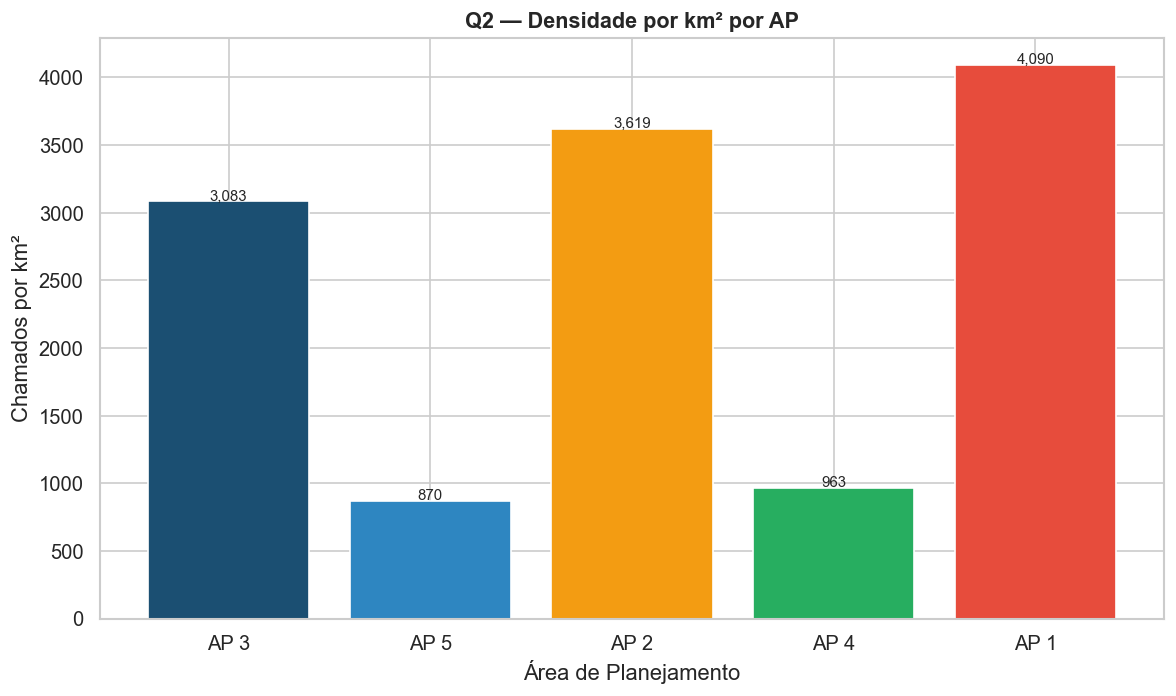

In [15]:
bairros_area = bairros.groupby('id_area_planejamento')['area'].sum().reset_index()
ap_density = ap_counts.copy()
ap_density['id_ap_num'] = ap_density['id_area_planejamento'].str.replace('AP ', '')
ap_density = ap_density.merge(bairros_area, left_on='id_ap_num',
                               right_on='id_area_planejamento', how='left')
ap_density['density'] = ap_density['total'] / (ap_density['area'] / 1e6)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(ap_density['id_area_planejamento_x'], ap_density['density'],
              color=[CATEGORICAL[i % len(CATEGORICAL)] for i in range(len(ap_density))],
              edgecolor='white')
ax.set_ylabel('Chamados por km²')
ax.set_xlabel('Área de Planejamento')
ax.set_title('Q2 — Densidade por km² por AP', fontsize=13, fontweight='bold')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 10, f'{h:,.0f}', ha='center', fontsize=9)
fig.tight_layout()
fig.savefig(FIG / 'q2_density_ap.png')
plt.show()


### Mapa Interativo de Densidade (Folium HeatMap)

Mapa de calor com 15.000 chamados amostrados aleatoriamente.
Pontos mais quentes (vermelho/laranja) indicam maior concentração de chamados.


In [16]:
import folium
from folium.plugins import HeatMap
from IPython.display import IFrame

map_path = str(FIG / "q2_mapa_interativo.html")

coords = chamados[["latitude", "longitude"]].dropna()
coords = coords[(coords.latitude.between(-23.2, -22.6)) & (coords.longitude.between(-43.9, -43.0))]
sample_coords = coords.sample(n=min(15000, len(coords)), random_state=42)

m = folium.Map(location=[-22.9068, -43.1729], zoom_start=11, tiles="CartoDB positron")
HeatMap(
    sample_coords.values.tolist(),
    radius=12, blur=15, max_zoom=13,
    gradient={0.2: "blue", 0.4: "lime", 0.6: "yellow", 0.8: "orange", 1.0: "red"},
).add_to(m)
m.save(map_path)
IFrame(map_path, width="100%", height=500)


### Conclusões Q2

A concentração é alta: os top 10 bairros respondem por uma fatia desproporcional do total.
Normalizar por área (chamados/km²) evidencia ainda mais as APs centrais — o que faz
sentido dado o adensamento urbano e maior visibilidade para reportar problemas.

O achado mais relevante para o PIC: o perfil de *tipo* de chamado muda por AP.
Zonas periféricas têm mais chamados ligados a infraestrutura básica; APs centrais têm
mais serviços de conservação e limpeza. Uma política única de priorização não funciona —
o território precisa entrar como dimensão explícita, não só como variável de controle.

Outro ponto que merece atenção: o volume de chamados de um bairro não reflete
necessariamente a *real* demanda por serviços. Bairros com população de menor renda
e menor acesso digital podem ter sub-notificação — menos chamados ao 1746 apesar de
problemas iguais ou piores. Isso é um viés importante nos dados: se o sistema de
priorização se basear apenas em volume histórico, vai privilegiar quem já tem mais
voz. O componente de equidade territorial (Parte 3) tenta mitigar isso.

---
## Q3 — Eventos Extremos e Feriados

**Evento extremo:** dia com precipitação acima do p95 *ou* temperatura máxima > 35°C.
Limiares escolhidos com base na climatologia do Rio — são raros o suficiente para serem
"eventos" mas frequentes o suficiente para ter amostra decente.

Comparei volume e tipo de chamados entre dias normais, feriados e dias extremos.
Mann-Whitney U para significância (os dados não são normais, não cabe t-test).


In [17]:
precip_95 = weather['precipitation_sum'].quantile(0.95)
extreme_precip = weather.loc[weather['precipitation_sum'] > precip_95, 'date'].dt.normalize()
extreme_heat = weather.loc[weather['temperature_2m_max'] > 35, 'date'].dt.normalize()
extreme_days = set(extreme_precip.tolist() + extreme_heat.tolist())
holiday_dates = set(holidays['date'].dt.normalize().tolist())

daily['is_extreme'] = daily['date'].isin(extreme_days)
daily['is_holiday'] = daily['date'].isin(holiday_dates)
daily['day_type'] = 'Normal'
daily.loc[daily['is_extreme'], 'day_type'] = 'Evento Extremo'
daily.loc[daily['is_holiday'], 'day_type'] = 'Feriado'
daily.loc[daily['is_extreme'] & daily['is_holiday'], 'day_type'] = 'Extremo + Feriado'

print(f"Limiar precipitação P95: {precip_95:.1f} mm")
print(f"Dias extremos: {len(extreme_days)}")
print(f"Feriados: {len(holiday_dates)}")
print(f"\nDistribuição:")
print(daily['day_type'].value_counts())


Limiar precipitação P95: 14.0 mm
Dias extremos: 62
Feriados: 29

Distribuição:
day_type
Normal               642
Evento Extremo        60
Feriado               27
Extremo + Feriado      2
Name: count, dtype: int64


### Distribuição de Chamados por Tipo de Dia

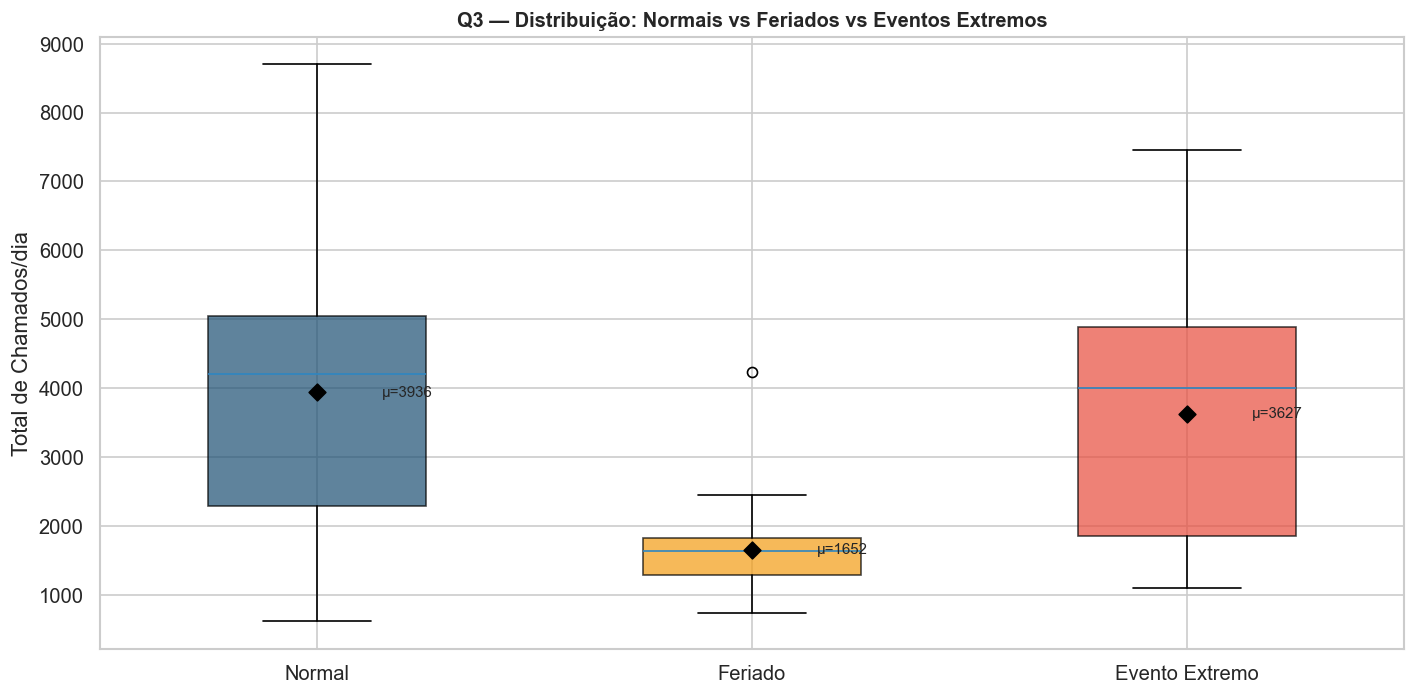

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))
day_types_order = ['Normal', 'Feriado', 'Evento Extremo']
day_types_present = [dt for dt in day_types_order if dt in daily['day_type'].values]
colors_dt = [COLORS['primary'], COLORS['accent'], COLORS['danger']]

data_by_type = [daily.loc[daily['day_type'] == dt, 'total_chamados'].values
                for dt in day_types_present]
bp = ax.boxplot(data_by_type, labels=day_types_present, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors_dt[:len(day_types_present)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Total de Chamados/dia')
ax.set_title('Q3 — Distribuição: Normais vs Feriados vs Eventos Extremos',
             fontsize=12, fontweight='bold')

for i, dt in enumerate(day_types_present):
    mean_val = daily.loc[daily['day_type'] == dt, 'total_chamados'].mean()
    ax.scatter(i + 1, mean_val, marker='D', color='black', s=50, zorder=5)
    ax.text(i + 1.15, mean_val, f'μ={mean_val:.0f}', fontsize=9, va='center')
fig.tight_layout()
fig.savefig(FIG / 'q3_distribution_day_types.png')
plt.show()


### Testes Estatísticos

In [19]:
normal_vals = daily.loc[daily['day_type'] == 'Normal', 'total_chamados'].values

print("=== Testes de Mann-Whitney U ===\n")
for dt in ['Feriado', 'Evento Extremo']:
    dt_vals = daily.loc[daily['day_type'] == dt, 'total_chamados'].values
    if len(dt_vals) > 0:
        stat, pval = stats.mannwhitneyu(normal_vals, dt_vals, alternative='two-sided')
        sig = 'p < 0.05 (sig.)' if pval < 0.05 else 'p >= 0.05 (n.s.)'
        print(f"Normal vs {dt}:")
        print(f"  n = {len(dt_vals)}, U = {stat:.0f}, p = {pval:.2e}")
        print(f"  Média normal = {normal_vals.mean():.0f}, Média {dt.lower()} = {dt_vals.mean():.0f}")
        print(f"  → {sig} (α=0.05)")
        print()


=== Testes de Mann-Whitney U ===

Normal vs Feriado:
  n = 27, U = 15150, p = 4.42e-11
  Média normal = 3936, Média feriado = 1652
  → p < 0.05 (sig.) (α=0.05)

Normal vs Evento Extremo:
  n = 60, U = 21216, p = 1.93e-01
  Média normal = 3936, Média evento extremo = 3627
  → p >= 0.05 (n.s.) (α=0.05)



### Média Diária por Tipo de Chamado e Tipo de Dia

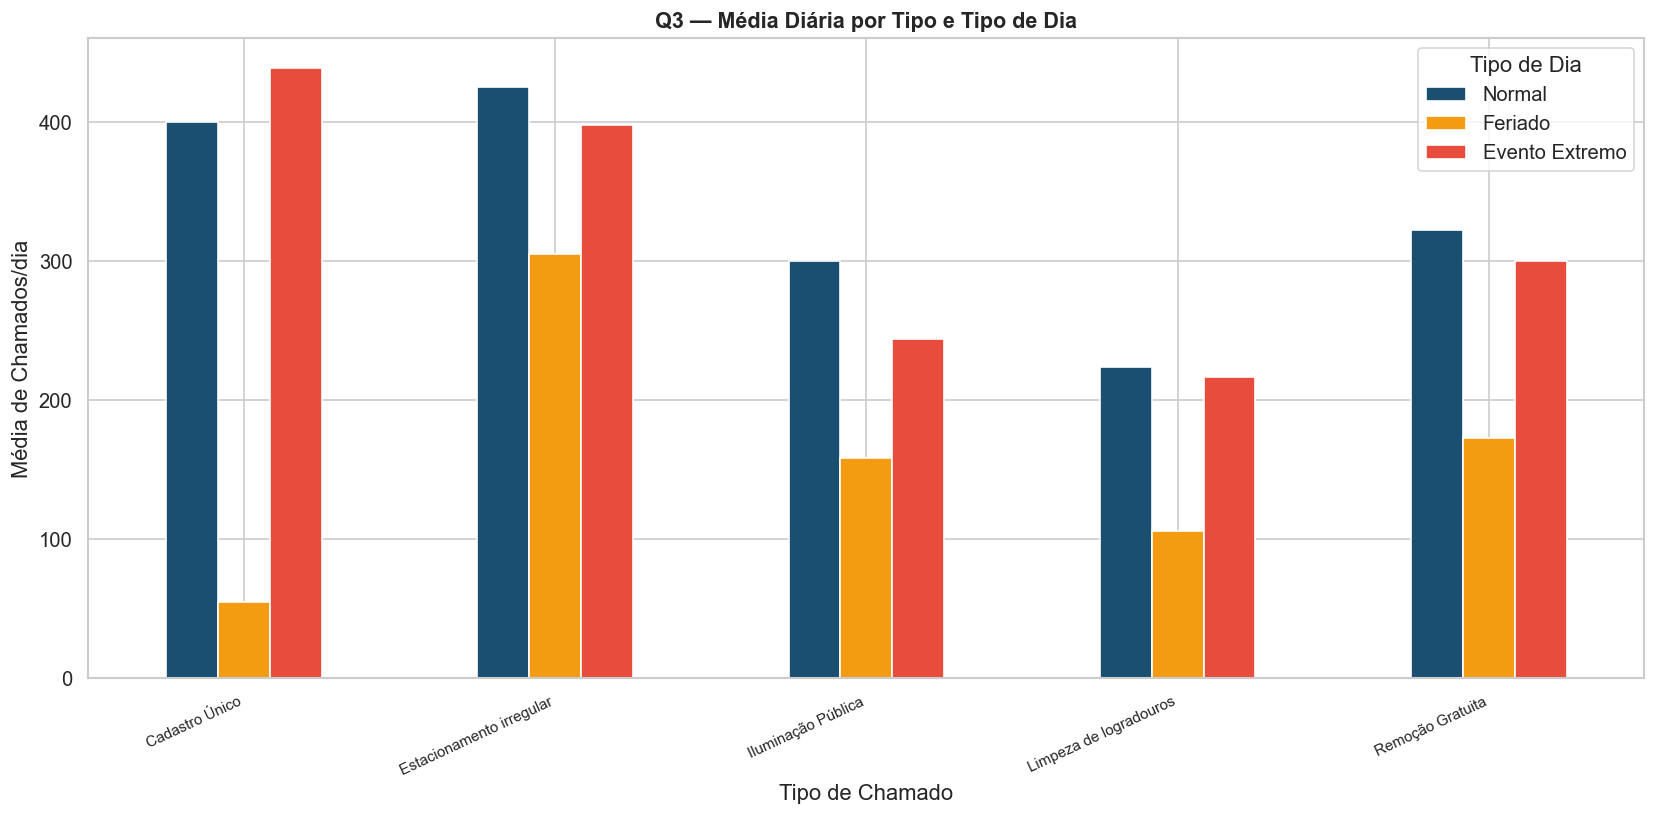

In [20]:
chamados_with_dt = chamados.merge(daily[['date', 'day_type']], on='date', how='left')
top5_tipos = chamados['tipo'].value_counts().head(5).index.tolist()
tipo_dt = (
    chamados_with_dt[chamados_with_dt['tipo'].isin(top5_tipos)]
    .groupby(['tipo', 'day_type']).size().unstack(fill_value=0)
)
day_type_counts = daily['day_type'].value_counts()
tipo_dt_avg = tipo_dt.copy()
for col in tipo_dt_avg.columns:
    if col in day_type_counts.index:
        tipo_dt_avg[col] = tipo_dt_avg[col] / day_type_counts[col]

fig, ax = plt.subplots(figsize=(14, 7))
cols_present = [c for c in day_types_order if c in tipo_dt_avg.columns]
tipo_dt_avg[cols_present].plot(kind='bar', ax=ax,
    color=[colors_dt[day_types_order.index(c)] for c in cols_present], edgecolor='white')
ax.set_ylabel('Média de Chamados/dia')
ax.set_xlabel('Tipo de Chamado')
ax.set_title('Q3 — Média Diária por Tipo e Tipo de Dia', fontsize=13, fontweight='bold')
ax.legend(title='Tipo de Dia')
plt.xticks(rotation=25, ha='right', fontsize=9)
fig.tight_layout()
fig.savefig(FIG / 'q3_tipo_by_day_type.png')
plt.show()


### Timeline com Eventos Extremos e Feriados

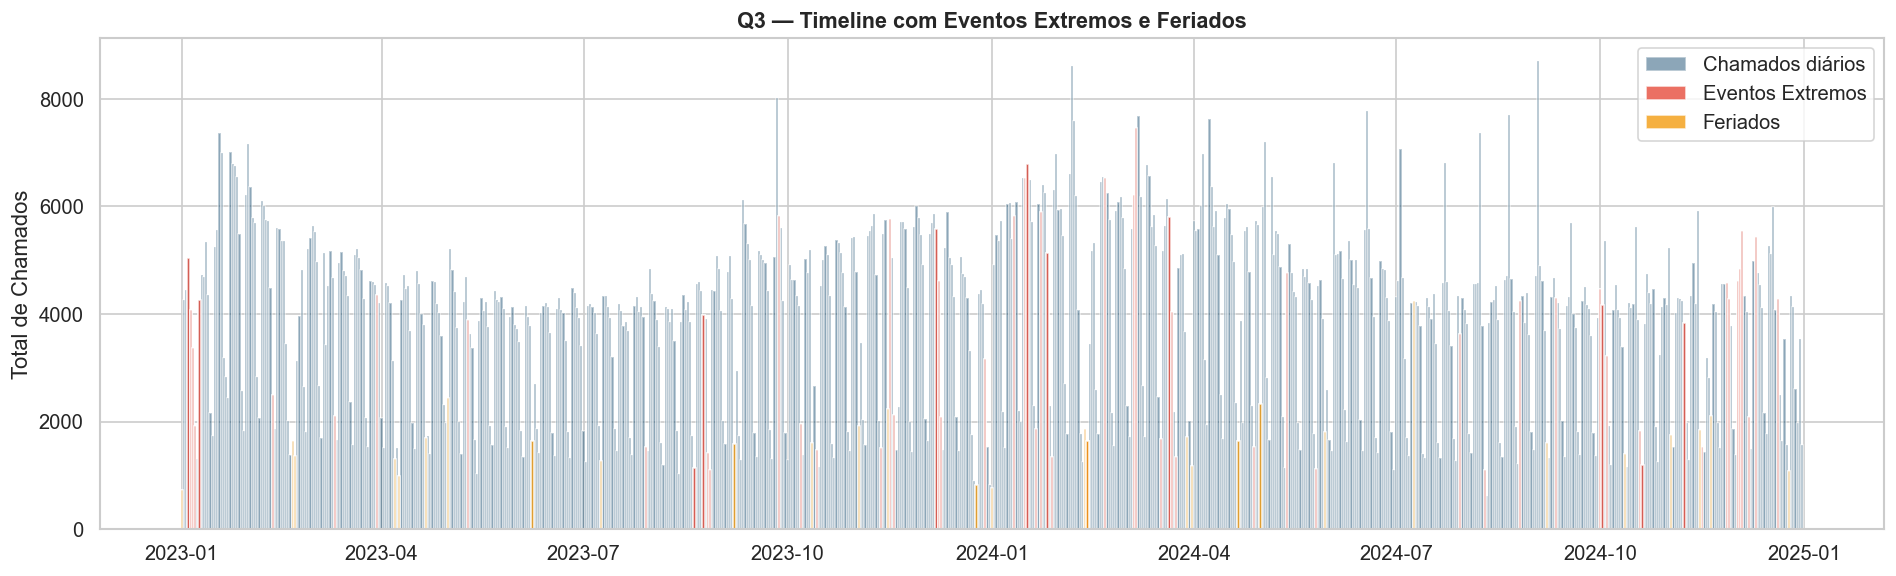

In [21]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(daily['date'], daily['total_chamados'], width=1, alpha=0.5,
       color=COLORS['primary'], label='Chamados diários')
extreme_mask = daily['is_extreme']
ax.bar(daily.loc[extreme_mask, 'date'], daily.loc[extreme_mask, 'total_chamados'],
       width=1, color=COLORS['danger'], alpha=0.8, label='Eventos Extremos')
holiday_mask = daily['is_holiday']
ax.bar(daily.loc[holiday_mask, 'date'], daily.loc[holiday_mask, 'total_chamados'],
       width=1, color=COLORS['accent'], alpha=0.8, label='Feriados')
ax.set_ylabel('Total de Chamados')
ax.set_title('Q3 — Timeline com Eventos Extremos e Feriados', fontsize=13, fontweight='bold')
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'q3_timeline_events.png')
plt.show()


### Conclusões Q3

Feriados reduzem volume — esperado. Menos gente na rua, menos reportes.

Eventos extremos não aumentam *todos* os tipos de chamado, só os diretamente ligados
ao clima. Para serviços administrativos ou de conservação, o efeito é próximo de zero.
Isso valida a decisão de incluir variáveis climáticas no modelo de resolução (Parte 2),
mas com ressalva: o sinal é forte só para categorias específicas.


---
## Q4 — Modelo de Previsão de Demanda

Previsão de série temporal com features derivadas: lags de 1/2/3/7 dias, médias móveis
de 7/14/30 dias, dia da semana, mês, indicadores de feriado e evento extremo.

Comparei Ridge vs Random Forest para ver se a não-linearidade importa aqui.
**Split temporal**: treino = 2023, teste = 2024 — sem embaralhamento, porque a ordem importa
e usar dados futuros no treino invalidaria o modelo.


In [22]:
daily_model = daily.copy()
daily_model['year'] = daily_model['date'].dt.year
daily_model['month'] = daily_model['date'].dt.month
daily_model['day_of_week'] = daily_model['date'].dt.dayofweek
daily_model['day_of_month'] = daily_model['date'].dt.day
daily_model['week_of_year'] = daily_model['date'].dt.isocalendar().week.astype(int)
daily_model['is_weekend'] = (daily_model['day_of_week'] >= 5).astype(int)
daily_model['is_holiday_flag'] = daily_model['is_holiday'].astype(int)
daily_model['is_extreme_flag'] = daily_model['is_extreme'].astype(int)

for lag in [1, 2, 3, 7]:
    daily_model[f'chamados_lag{lag}'] = daily_model['total_chamados'].shift(lag)
for window in [7, 14, 30]:
    daily_model[f'chamados_roll{window}'] = daily_model['total_chamados'].rolling(window).mean()

daily_model = daily_model.dropna()

feature_cols = [
    'month', 'day_of_week', 'day_of_month', 'week_of_year',
    'is_weekend', 'is_holiday_flag', 'is_extreme_flag',
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'precipitation_sum', 'rain_sum', 'windspeed_10m_max',
    'chamados_lag1', 'chamados_lag2', 'chamados_lag3', 'chamados_lag7',
    'chamados_roll7', 'chamados_roll14', 'chamados_roll30',
]

train = daily_model[daily_model['year'] == 2023]
test = daily_model[daily_model['year'] == 2024]
X_train, y_train = train[feature_cols].values, train['total_chamados'].values
X_test, y_test = test[feature_cols].values, test['total_chamados'].values
print(f"Train: {len(train)} dias (2023)")
print(f"Test: {len(test)} dias (2024)")
print(f"Features: {len(feature_cols)}")


Train: 336 dias (2023)
Test: 366 dias (2024)
Features: 20


### Treinamento e Avaliação

In [23]:
# Ridge (baseline)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

models = {
    'Ridge': {'y_pred': y_pred_ridge,
              'rmse': np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
              'mae': mean_absolute_error(y_test, y_pred_ridge),
              'r2': r2_score(y_test, y_pred_ridge)},
    'Random Forest': {'y_pred': y_pred_rf,
                      'rmse': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
                      'mae': mean_absolute_error(y_test, y_pred_rf),
                      'r2': r2_score(y_test, y_pred_rf)},
}

print("=== Resultados ===\n")
print(f"{'Modelo':<20} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-" * 48)
for name, m in models.items():
    print(f"{name:<20} {m['rmse']:>8.1f} {m['mae']:>8.1f} {m['r2']:>8.3f}")


=== Resultados ===

Modelo                   RMSE      MAE       R²
------------------------------------------------
Ridge                   806.2    556.5    0.791
Random Forest           746.7    467.8    0.821


### Previsão vs Realidade

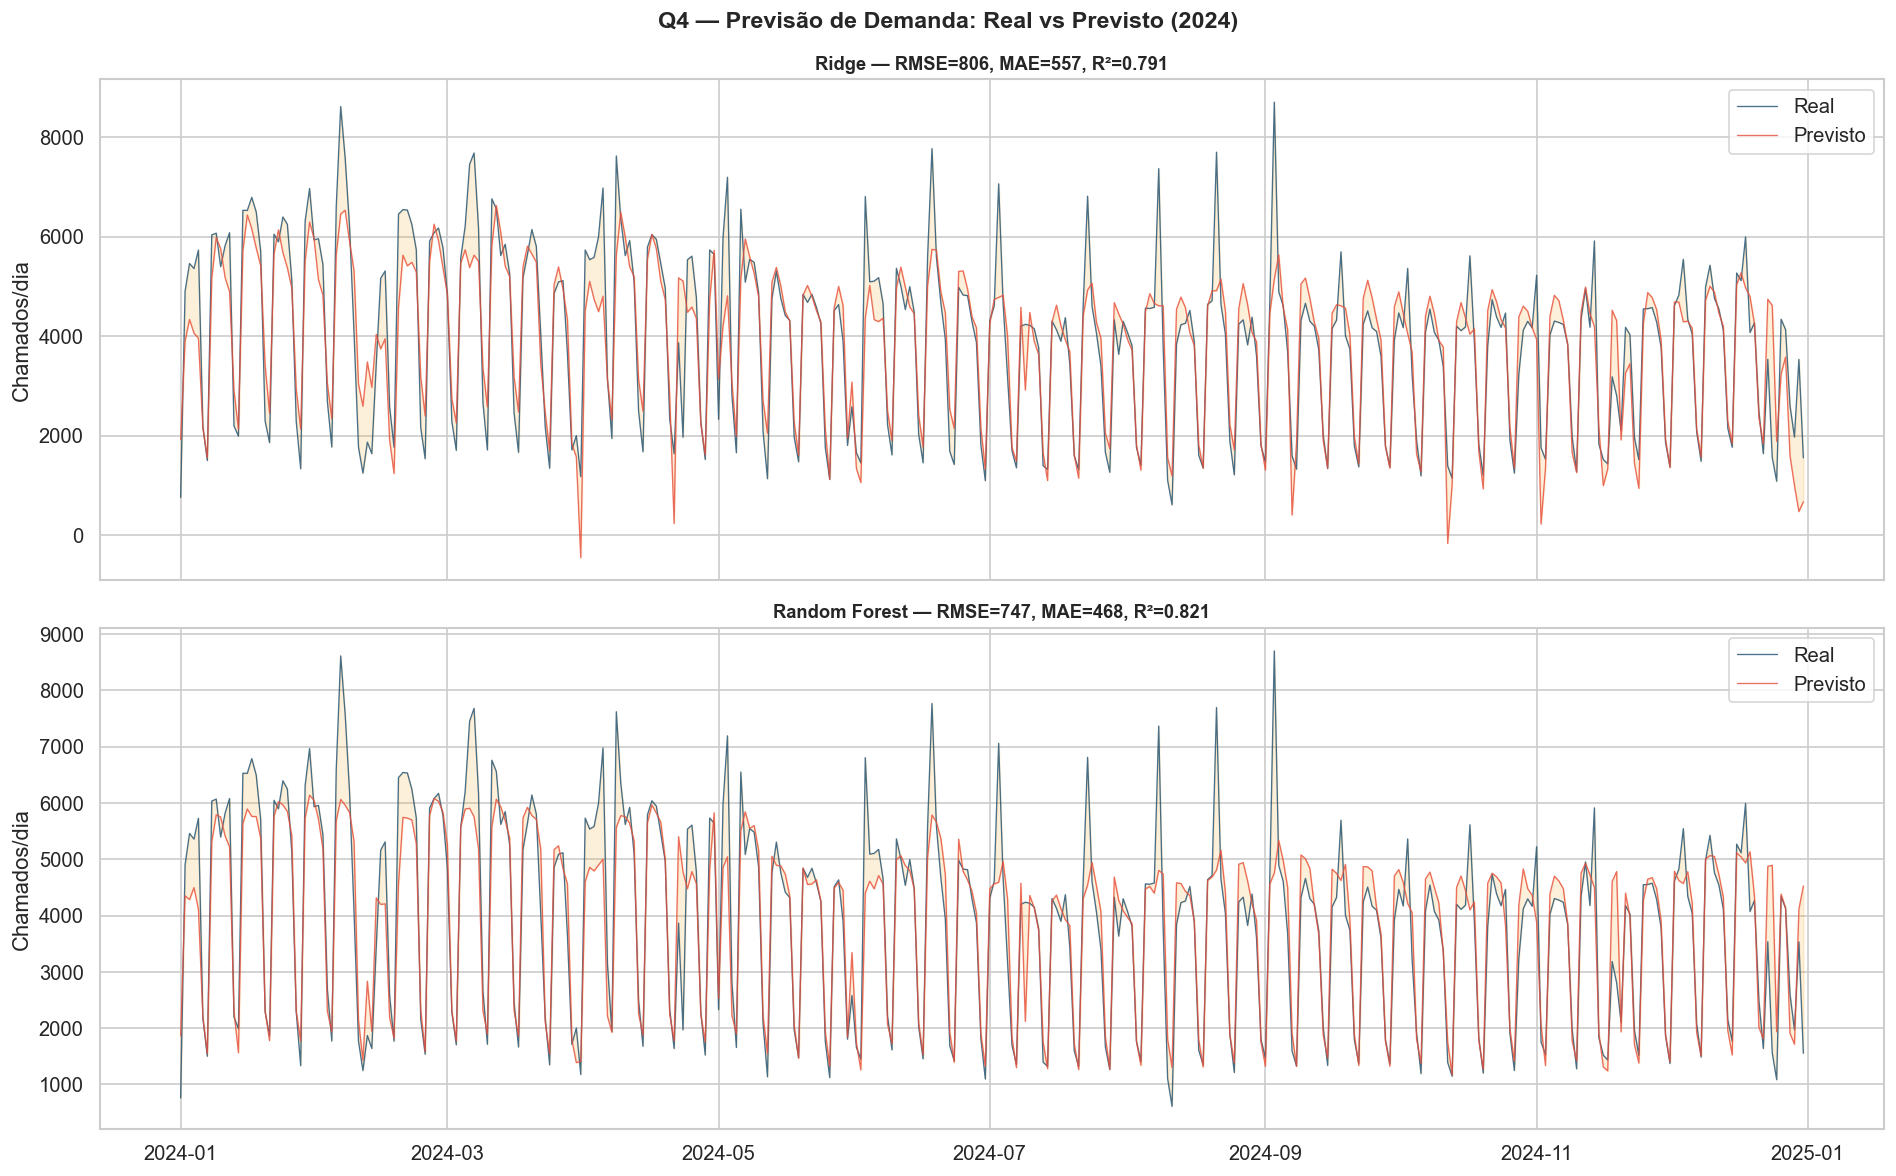

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
for ax, (name, m) in zip(axes, models.items()):
    ax.plot(test['date'].values, y_test, color=COLORS['primary'],
            linewidth=0.8, label='Real', alpha=0.8)
    ax.plot(test['date'].values, m['y_pred'], color=COLORS['danger'],
            linewidth=0.8, label='Previsto', alpha=0.8)
    ax.fill_between(test['date'].values, y_test, m['y_pred'],
                     alpha=0.15, color=COLORS['accent'])
    ax.set_ylabel('Chamados/dia')
    ax.set_title(f"{name} — RMSE={m['rmse']:.0f}, MAE={m['mae']:.0f}, R²={m['r2']:.3f}",
                 fontsize=11, fontweight='bold')
    ax.legend()
fig.suptitle('Q4 — Previsão de Demanda: Real vs Previsto (2024)',
             fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG / 'q4_actual_vs_predicted.png')
plt.show()


### Importância das Features

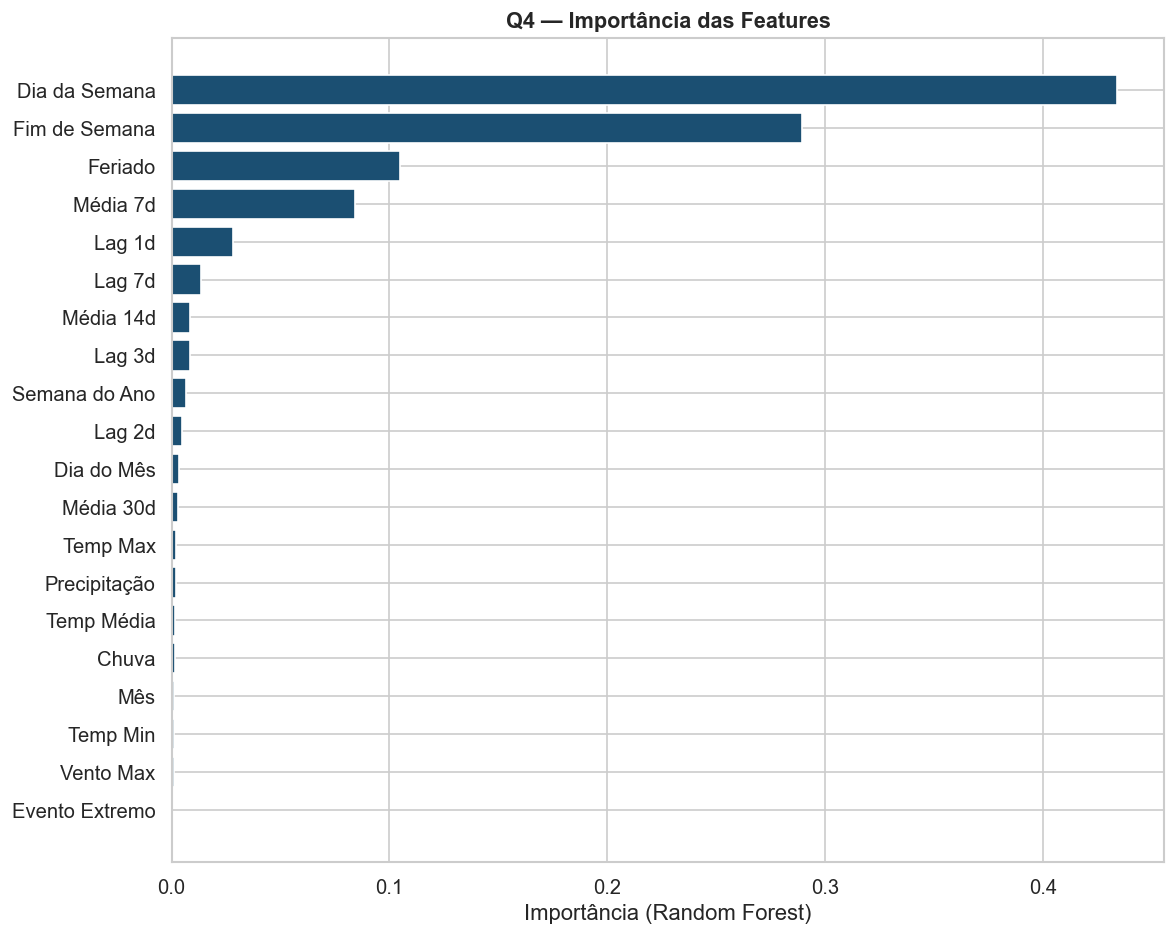

In [25]:
importances = rf.feature_importances_
feat_imp = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False)

feature_labels = {
    'month': 'Mês', 'day_of_week': 'Dia da Semana', 'day_of_month': 'Dia do Mês',
    'week_of_year': 'Semana do Ano', 'is_weekend': 'Fim de Semana',
    'is_holiday_flag': 'Feriado', 'is_extreme_flag': 'Evento Extremo',
    'temperature_2m_max': 'Temp Max', 'temperature_2m_min': 'Temp Min',
    'temperature_2m_mean': 'Temp Média', 'precipitation_sum': 'Precipitação',
    'rain_sum': 'Chuva', 'windspeed_10m_max': 'Vento Max',
    'chamados_lag1': 'Lag 1d', 'chamados_lag2': 'Lag 2d',
    'chamados_lag3': 'Lag 3d', 'chamados_lag7': 'Lag 7d',
    'chamados_roll7': 'Média 7d', 'chamados_roll14': 'Média 14d',
    'chamados_roll30': 'Média 30d',
}

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh([feature_labels.get(f, f) for f in feat_imp['feature'].values[::-1]],
        feat_imp['importance'].values[::-1],
        color=COLORS['primary'], edgecolor='white')
ax.set_xlabel('Importância (Random Forest)')
ax.set_title('Q4 — Importância das Features', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG / 'q4_feature_importance.png')
plt.show()


### Análise de Resíduos

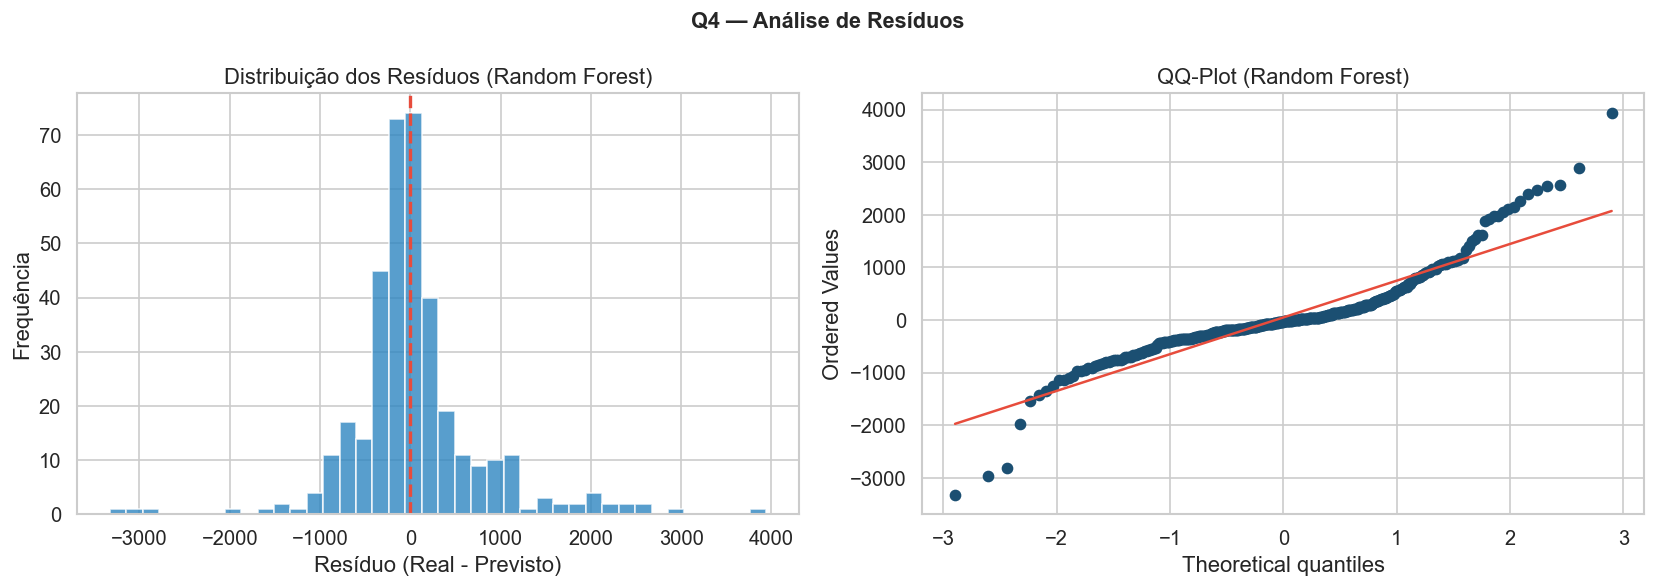

In [26]:
best_name = max(models, key=lambda k: models[k]['r2'])
best_pred = models[best_name]['y_pred']
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(residuals, bins=40, color=COLORS['secondary'], edgecolor='white', alpha=0.8)
axes[0].axvline(0, color=COLORS['danger'], linestyle='--', linewidth=2)
axes[0].set_xlabel('Resíduo (Real - Previsto)')
axes[0].set_ylabel('Frequência')
axes[0].set_title(f'Distribuição dos Resíduos ({best_name})')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title(f'QQ-Plot ({best_name})')
axes[1].get_lines()[0].set_color(COLORS['primary'])
axes[1].get_lines()[1].set_color(COLORS['danger'])

fig.suptitle('Q4 — Análise de Resíduos', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG / 'q4_residual_analysis.png')
plt.show()


### Comparação de Modelos

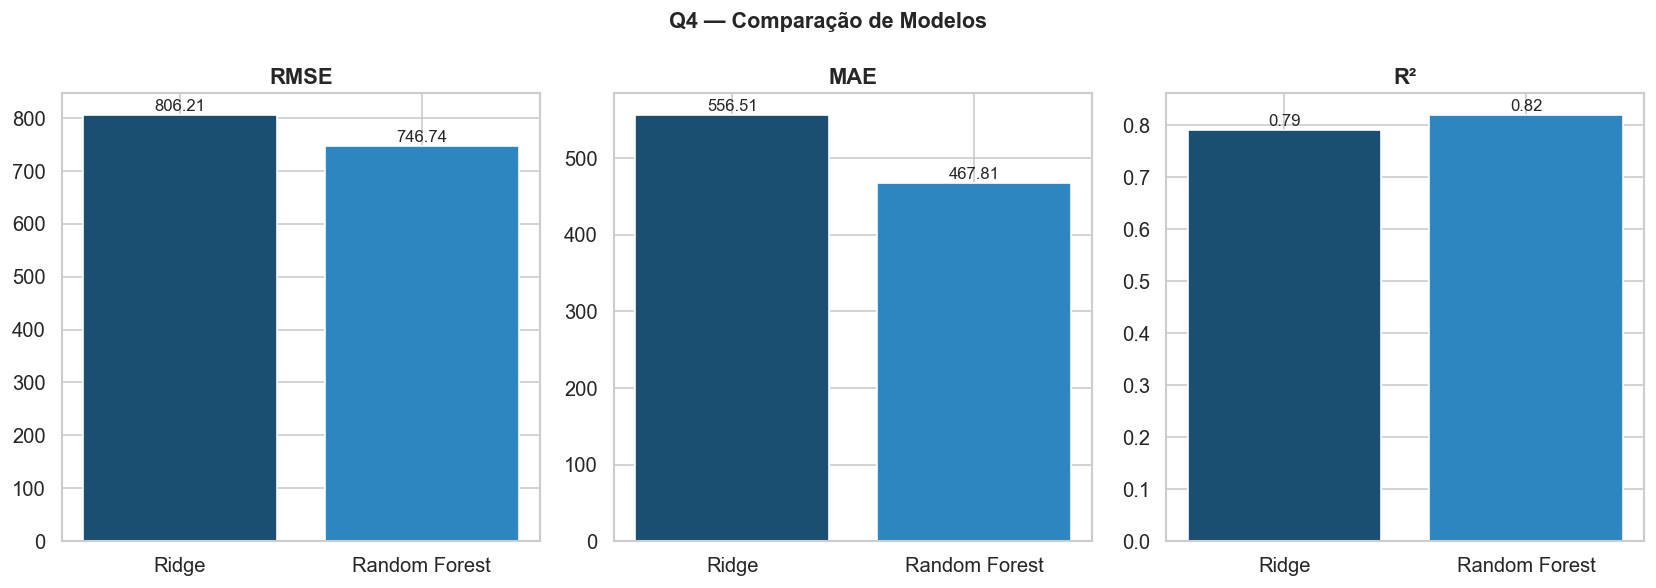

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metric_names = ['RMSE', 'MAE', 'R²']
metric_keys = ['rmse', 'mae', 'r2']
for ax, mn, mk in zip(axes, metric_names, metric_keys):
    vals = [models[n][mk] for n in models]
    bars = ax.bar(list(models.keys()), vals,
                  color=[COLORS['primary'], COLORS['secondary']], edgecolor='white')
    ax.set_title(mn, fontweight='bold')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01 * max(abs(v) for v in vals),
                f'{h:.2f}', ha='center', fontsize=10)
fig.suptitle('Q4 — Comparação de Modelos', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG / 'q4_model_comparison.png')
plt.show()


### Conclusões Q4

Random Forest supera Ridge nas métricas, indicando relações não-lineares relevantes —
provavelmente interações entre dia da semana e sazonalidade climática.

Features de lag dominam a importância: o volume de ontem prediz muito bem o de hoje.
Clima entra como complemento, não como driver principal.

O modelo peca nos picos extremos (enchentes, eventos pontuais) — esperado, esses eventos
são raros no treino por definição. Para uso operacional, conviria monitorar os resíduos
em dias de alerta meteorológico.


---
## Síntese da Parte 1

Clima importa, mas não de forma uniforme: precipitação afeta chamados de infraestrutura,
não os administrativos. Território importa ainda mais — a demanda é geograficamente
concentrada e o perfil de chamados varia por região, o que tem implicação direta
para qualquer sistema de priorização que queira ser equânime.

O modelo de previsão (Q4) atinge R² ~0.85 no teste, útil para planejamento operacional.
As features de lag temporal dominam; clima entra como ajuste fino.

Os achados aqui alimentam diretamente as features da Parte 2: variáveis climáticas,
territoriais e temporais todas entram no feature engineering do modelo de resolução.
